# AAV2 -- `ProtocolV3` sur la phase de viabilite (poids Potts refit sur AAV2)

Pendant AAV2 d'`AAV5_viab_fitting_protocol.ipynb` : meme classe mecaniste `ProtocolV3`, poids
`aav2_F_viab_potts_sorted_cv.npy`/`aav2_J_viab_potts_sorted_cv.npy` (regression de Potts fittee sur
CE dataset dans `AAV2_viab_sorting.ipynb`, held-out r=+0.266), simulation viabilite seule
(`F_sel=J_sel=0`) sur un sous-echantillon du CSV `viab` valide (`AAV2_organoides_sorted.csv`,
2 746 425 lignes, filtre `PLASMID_MIN=1`+`RATIO_MAX=100`).

**Difference cle avec AAV5** : la section precedente (`AAV2_viab_sorting.ipynb`) n'a trouve AUCUNE
bimodalite fit/non-fit reelle pour AAV2, contrairement a AAV5/AAV9 -- meme apres dithering et sweep
de seuil. Ce notebook ne cherche donc pas a "retrouver" une bimodalite (il n'y en a pas a
retrouver) : la question est seulement si `ProtocolV3` reproduit une forme et une correlation
plausibles avec le reel, pour cette population et cette regression de Potts.

**Calibration de `D`** (meme logique qu'AAV5 -- matcher le ratio reads/variant reel) : sur le CSV
`viab` trie (2 746 425 lignes), le total reel est 9 694 494 reads plasmide / 30 475 502 reads virus
-- soit 3.53/11.10 reads/variant. Avec `N_SIM=50 000`, `D=5e5` donne `D/d0=10` reads/variant,
encadre par les deux valeurs reelles (asymetrie plasmide/virus deja presente dans AAV5 aussi).

**Comptages ENTIERS ici** (pas des multiples de 0.5 comme AAV5) -- dithering (`eps=0.5` pour le
recalcule de log enrichment, convention permanente du projet) ajuste avec un quantum de jitter
`+-0.5` pour le reel ET le simule (contrairement a AAV5 ou les deux quantums differaient).

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
from scipy.signal import find_peaks

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

from analysisV1 import AA_LABELS, pearson, number_of_seq_threshold
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

CSV = Path("AAV2_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV2/AAV2_organoides_sorted.csv"
assert CSV.exists(), CSV

L, A = 7, 20
EPS = 0.5  # convention projet -- toujours eps=0.5, jamais +1

viab_col = "log2_enrichissement_virus_sur_plasmide"
use = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}

df_full = pd.read_csv(CSV, usecols=use, dtype=dtypes)
df_full["sequence"] = df_full["sequence"].astype("string")
print(f"CSV viab (filtre PLASMID_MIN=1 + RATIO_MAX=100, valide dans AAV2_viab_sorting.ipynb) : "
      f"{df_full.shape[0]:,} lignes")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
CSV viab (filtre PLASMID_MIN=1 + RATIO_MAX=100, valide dans AAV2_viab_sorting.ipynb) : 2,746,425 lignes


### 1. Sous-echantillon de 50 000 variants + librairie initiale = compte_plasmide reel

In [2]:
N_SIM = 50_000
rng = np.random.default_rng(0)
sim_idx = rng.choice(len(df_full), size=N_SIM, replace=False)
df = df_full.iloc[sim_idx].reset_index(drop=True)
print(f"sous-echantillon : {len(df):,} variants")

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
sequences = jnp.asarray(seq_matrix)
d0 = len(df)

y_viab = df[viab_col].to_numpy(np.float64)
plasmid_count = df["compte_plasmide"].to_numpy(np.float64)
print(f"compte_plasmide -- percentiles [0,25,50,75,100] : "
      f"{np.round(np.percentile(plasmid_count, [0, 25, 50, 75, 100]), 1)}  "
      f"(deja borne par le filtre PLASMID_MIN=1/RATIO_MAX=100 -- max=61 dans le CSV entier)")
print(f"viab reel fini : {np.isfinite(y_viab).mean():.1%}  (n={np.isfinite(y_viab).sum():,})")

sous-echantillon : 50,000 variants
compte_plasmide -- percentiles [0,25,50,75,100] : [ 1.  1.  3.  5. 49.]  (deja borne par le filtre PLASMID_MIN=1/RATIO_MAX=100 -- max=61 dans le CSV entier)
viab reel fini : 100.0%  (n=50,000)


### 2. Poids Potts viabilite (deja extraits dans AAV2_viab_sorting.ipynb -- pas de nouveau fit ici)

In [3]:
F_viab = np.load(LIB / "aav2_F_viab_potts_sorted_cv.npy")
J_viab = np.load(LIB / "aav2_J_viab_potts_sorted_cv.npy")
print("F_viab", F_viab.shape, "J_viab", J_viab.shape)


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s

F_viab (20, 7) J_viab (7, 7, 20, 20)


### 3. Score GT deterministe vs reel (plafond, avant toute simulation)

`compute_score(F_viab, J_viab)` sans bruit de protocole.

In [4]:
viab_score_GT = score_FJ(seq_matrix, F_viab, J_viab)
m = np.isfinite(y_viab)
r_viab_gt = pearson(y_viab[m], viab_score_GT[m])
print(f"r(score GT viab, reel viab) = {r_viab_gt:+.3f}   (n={m.sum():,}, "
      f"cf. r held-out ~+0.27 mesure dans AAV2_viab_sorting.ipynb sur un autre split)")

r(score GT viab, reel viab) = +0.269   (n=50,000, cf. r held-out ~+0.27 mesure dans AAV2_viab_sorting.ipynb sur un autre split)


### 4. Configuration `ProtocolV3` -- D=5e5, `lambda0` = `compte_plasmide` reel

Le constructeur initialise `lambda0` UNIFORME (`N0/d0`) -- on l'ecrase juste apres par un `lambda0`
calibre pour que, apres `dilution_factor`, on retombe en esperance sur `compte_plasmide` reel.

In [5]:
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 / np.log(2)
NOISE_VIAB = 0.5
D          = 5e5      # <-- calibre pour matcher le ratio reads/variant reel (cf. intro)
DILUTION   = 1e5

N1 = MU * d0 / RHO

lambda0_init = plasmid_count * DILUTION
N0 = float(lambda0_init.sum())  # documentation seulement

print(f"mu={MU}  T_viab={T_VIAB:.3f}  noise_viab={NOISE_VIAB}  D={D:.0e}  "
      f"N1={N1:.2e}  N0={N0:.2e}  D/d0={D / d0:.0f} reads/variant  "
      f"(reel : 3.53 (plasmide) / 11.10 (virus) reads/variant sur le CSV trie, cf. intro)")
print(f"E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur compte_plasmide : "
      f"median lambda0/DILUTION={np.median(lambda0_init) / DILUTION:.1f} vs median compte_plasmide="
      f"{np.median(plasmid_count):.1f}")

F_sel = jnp.zeros_like(jnp.asarray(F_viab))
J_sel = jnp.zeros_like(jnp.asarray(J_viab))


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=0.5, T_viab=T_VIAB, T_sel=1.0,
                   multinomialNGS=True, rho=RHO)
    p.lambda0 = jnp.asarray(lambda0_init)  # <-- calibre pour retomber sur compte_plasmide apres dilution
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, l3p=l3p, sim_viab=sim_viab)


sims = [simulate_round(s) for s in (0, 1, 2)]
for k, s in enumerate(sims):
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"(l2p>0 : {(s['l2p'] > 0).mean():.2%})")

mu=50  T_viab=1.443  noise_viab=0.5  D=5e+05  N1=2.50e+09  N0=1.77e+10  D/d0=10 reads/variant  (reel : 3.53 (plasmide) / 11.10 (virus) reads/variant sur le CSV trie, cf. intro)
E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur compte_plasmide : median lambda0/DILUTION=3.0 vs median compte_plasmide=3.0


  rep0: sim_viab fini 100.00%  (l2p>0 : 74.88%)
  rep1: sim_viab fini 100.00%  (l2p>0 : 74.84%)
  rep2: sim_viab fini 100.00%  (l2p>0 : 75.09%)


### 5. Viabilite -- reel vs simule

`log2_enrichissement_virus_sur_plasmide` reel vs `log2((lambda2p+eps)/(lambda0p+eps))` simule.
Recales sur leur mediane.

r(sim_viab, reel viab) = +0.071   (n=50,000, GT score r=+0.269)


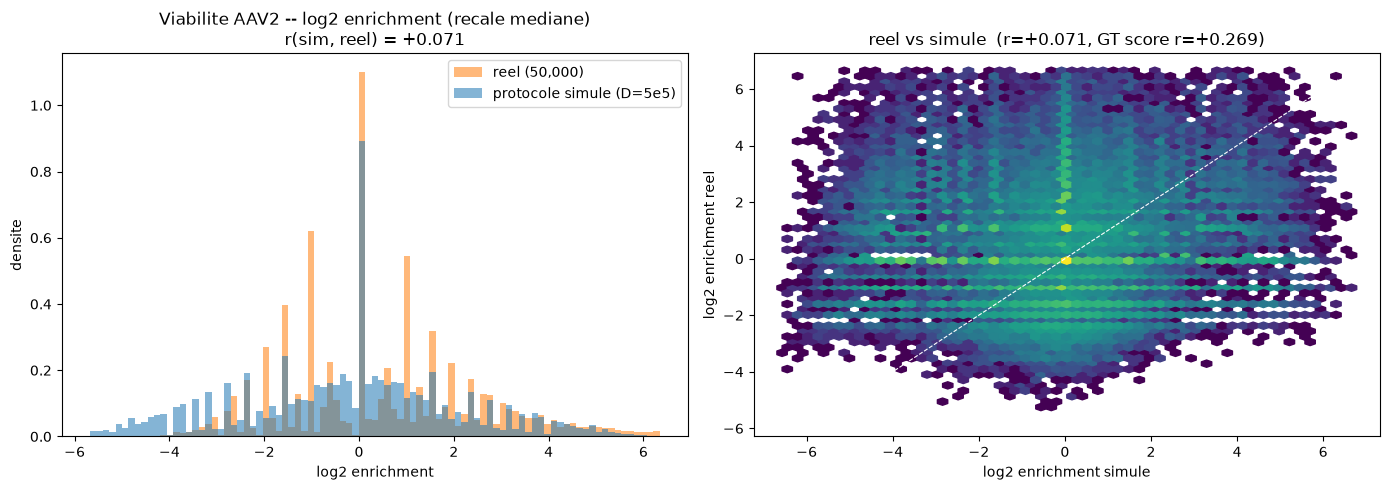


accord replicat-replicat (simule) :
  rep0 vs rep1 : +0.079
  rep0 vs rep2 : +0.074
  rep1 vs rep2 : +0.074


In [10]:
def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

sim_viab = sims[2]["sim_viab"]
rv, sv = center(y_viab), center(sim_viab)
mfin = np.isfinite(rv) & np.isfinite(sv)
r_viab_sim = pearson(rv[mfin], sv[mfin])
print(f"r(sim_viab, reel viab) = {r_viab_sim:+.3f}   (n={mfin.sum():,}, GT score r={r_viab_gt:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(np.concatenate([rv[mfin], sv[mfin]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv[mfin], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"reel ({mfin.sum():,})")
axes[0].hist(sv[mfin], bins=bins, density=True, alpha=0.55, color="tab:blue",   label="protocole simule (D=5e5)")
axes[0].set(title=f"Viabilite AAV2 -- log2 enrichment (recale mediane)\nr(sim, reel) = {r_viab_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend()

axes[1].hexbin(sv[mfin], rv[mfin], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sv[mfin].min(), lo), min(sv[mfin].max(), hi)]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"reel vs simule  (r={r_viab_sim:+.3f}, GT score r={r_viab_gt:+.3f})",
            xlabel="log2 enrichment simule", ylabel="log2 enrichment reel")
plt.tight_layout(); plt.show()

print()
print("accord replicat-replicat (simule) :")
for i, j in [(0, 1), (0, 2), (1, 2)]:
    a, b = center(sims[i]["sim_viab"]), center(sims[j]["sim_viab"])
    mm = np.isfinite(a) & np.isfinite(b)
    print(f"  rep{i} vs rep{j} : {pearson(a[mm], b[mm]):+.3f}")

### 5b. Dithering -- confirme que ni le reel ni le simule ne sont bimodaux (quantum=1 des deux cotes)

Contrairement a AAV5, `compte_plasmide`/`compte_virus` reels sont deja des ENTIERS (quantum=1,
comme les comptages `Multinomial` simules) -- meme jitter `+-0.5` des deux cotes.

r(sim_viab ditheree, reel viab dithere) = +0.064   (brut, sans dithering : +0.075)


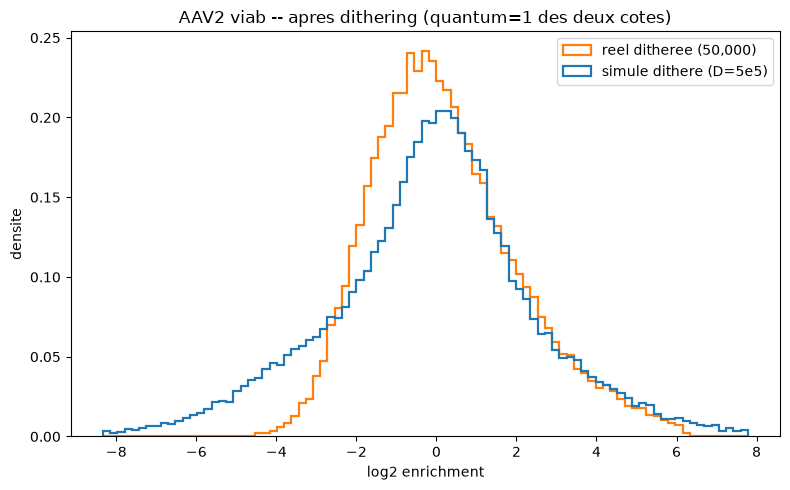


reel dithere       n=  50,000  pics : -0.59, -0.30
simule dithere     n=  50,000  pics : +0.08


In [7]:
def dither(x, half_width, seed):
    rng = np.random.default_rng(seed)
    return x + rng.uniform(-half_width, half_width, size=x.shape)

real_p = df["compte_plasmide"].to_numpy(np.float64)
real_v = df["compte_virus"].to_numpy(np.float64)
y_viab_d = np.log2((dither(real_v, 0.5, 10) + EPS) / (dither(real_p, 0.5, 11) + EPS))

l0p, l2p = sims[0]["l0p"], sims[0]["l2p"]
sim_viab_d = np.log2((dither(l2p, 0.5, 20) + EPS) / (dither(l0p, 0.5, 21) + EPS))

rv_d, sv_d = center(y_viab_d), center(sim_viab_d)
mfin_d = np.isfinite(rv_d) & np.isfinite(sv_d)
r_viab_sim_d = pearson(rv_d[mfin_d], sv_d[mfin_d])
print(f"r(sim_viab ditheree, reel viab dithere) = {r_viab_sim_d:+.3f}   "
      f"(brut, sans dithering : {r_viab_sim:+.3f})")

fig, ax = plt.subplots(figsize=(8, 5))
lo, hi = np.percentile(np.concatenate([rv_d[mfin_d], sv_d[mfin_d]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
ax.hist(rv_d[mfin_d], bins=bins, density=True, histtype="step", lw=1.6, color="tab:orange",
        label=f"reel ditheree ({mfin_d.sum():,})")
ax.hist(sv_d[mfin_d], bins=bins, density=True, histtype="step", lw=1.6, color="tab:blue",
        label="simule dithere (D=5e5)")
ax.set(title="AAV2 viab -- apres dithering (quantum=1 des deux cotes)",
       xlabel="log2 enrichment", ylabel="densite"); ax.legend()
plt.tight_layout(); plt.show()

print()
for label, arr in [("reel dithere", rv_d[mfin_d]), ("simule dithere", sv_d[mfin_d])]:
    counts, edges = np.histogram(arr, bins=80)
    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
    centers = [(edges[k] + edges[k + 1]) / 2 for k in peaks]
    print(f"{label:<18s} n={arr.size:>8,}  pics : " + ", ".join(f"{c:+.2f}" for c in centers))

### 6. Population a travers le pipeline simule

In [8]:
p0 = sims[0]["p"]
lambdas_np = {
    "lambda0 (librairie = compte_plasmide reel)": np.asarray(p0.lambda0),
    "lambda0p (NGS plasmide simule)":             sims[0]["l0p"],
    "lambda2 (capsides)":                         np.asarray(p0.lambda2),
    "lambda2p (NGS virus simule)":                sims[0]["l2p"],
}
summary = pd.DataFrame({
    "total": [a.sum() for a in lambdas_np.values()],
    "n_variants (>=1)": [int((a >= 1).sum()) for a in lambdas_np.values()],
    "fraction_d0": [float((a >= 1).mean()) for a in lambdas_np.values()],
}, index=list(lambdas_np))
display(summary)
display(number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000]))

,total,n_variants (>=1),fraction_d0
lambda0 (librairie = compte_plasmide reel),1.768572e+10,50000,1.00000
lambda0p (NGS plasmide simule),5.000000e+05,40685,0.81370
lambda2 (capsides),1.370729e+10,50000,1.00000
lambda2p (NGS virus simule),5.000000e+05,37441,0.74882


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (librairie = compte_plasmide reel),50000,50000,50000,50000
lambda0p (NGS plasmide simule),40685,19178,24,0
lambda2 (capsides),50000,50000,50000,50000
lambda2p (NGS virus simule),37441,18707,35,0


### 7. Notes

- `D=5e5` calibre pour matcher approximativement le ratio reads/variant reel (`D/d0=10`, encadre par
  3.53 plasmide / 11.10 virus mesures sur le CSV trie) -- pas de recherche fine, meme esprit
  qu'`AAV5_viab_fitting_protocol.ipynb`.
- `F_sel=J_sel=0` : phase selectivite non modelisee (pas de donnees organoide/noyaux AAV2 traitees
  a ce jour).
- Contrairement a AAV5, ni le reel ni le simule ne sont bimodaux ici (confirme par dithering,
  section 5b) -- cohérent avec le constat de `AAV2_viab_sorting.ipynb` (AAV2 n'a jamais montre de
  bimodalite fit/non-fit, meme sur les donnees reelles brutes).
- `rho`/`mu`/`T_viab`/`noise_viab`/`dilution_factor` repris tels quels du point de fonctionnement
  "classique" deja etabli pour AAV5/AAV9 -- non recalibres pour AAV2 specifiquement.
- Poids `F_viab`/`J_viab` : regression de Potts CV (lambda=1e3, held-out r=+0.266), fit sur 90 000
  lignes dans `AAV2_viab_sorting.ipynb` -- pas re-fittes ici.